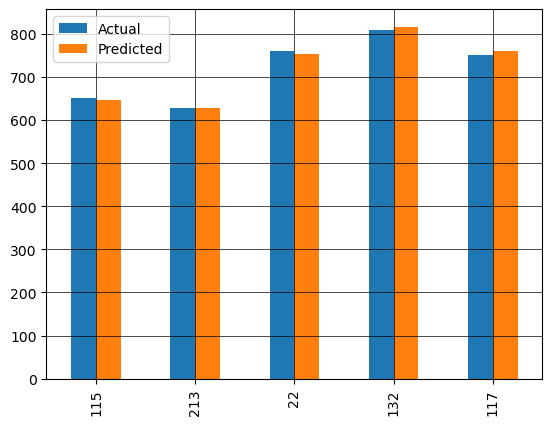

                        Coefficient
age                        0.204616
income                    74.726291
employment_length         -6.621284
loan_amount               32.074363
loan_term                  1.471273
number_of_credit_cards    -7.884975
number_of_dependents      -1.517046
existing_loans            13.371770
default_history           23.066700
education_level            9.112546
marital_status            12.839950
residence_type            25.718716
purpose_of_loan           -0.764420 

Mean Squared Error: 30.08533687818836
R^2 score: 0.9931311101997568



In [7]:
# Импорт требуемых библиотек
import pandas as pd
import matplotlib.pyplot as pplt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Загрузка датасета
dataset = pd.read_csv("credit_score_data.csv")

# Нормализация данных
dataset['income'] = MinMaxScaler().fit_transform(dataset[['income']])
dataset['loan_amount'] = StandardScaler().fit_transform(dataset[['loan_amount']])

# Разделение датасета
x = dataset.drop('credit_score', axis = 1)
y = dataset['credit_score']

# Создание тренировочных и тестировочных выборок
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.15, random_state = 42)

# Создание и обучение модели множественной линейной регрессии
regressor = LinearRegression()
regressor.fit(x_train, y_train)

# Создание предсказаний
y_pred = regressor.predict(x_test)

# Создание таблицы содержащей истинные и предсказанные значения
df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# Визуализация результатов в виде гистограммы
df[:5].plot(kind = 'bar')
pplt.grid(which = 'major', linestyle = '-', linewidth = '0.5', color = 'black')
pplt.grid(which = 'minor', linestyle = ':', linewidth = '0.5', color = 'black')
pplt.show()

# Вывод коэффициентов
coef_df = pd.DataFrame(regressor.coef_, x.columns, columns = ['Coefficient'])
print(coef_df, '\n')

# Вывод метрик оценки точности
print(f"Mean Squared Error: {metrics.mean_squared_error(y_test, y_pred)}")
print(f"R^2 score: {metrics.r2_score(y_test, y_pred)}\n")